# NB02b: MS DOWNLOAD

> Copyright (C) 2024-2026 Marco Heinzen - SPDX-License-Identifier: AGPL-3.0-or-later
> Part of the Master Thesis "Building Damage Assessment with Multimodal Satellite Time Series and Machine Learning in the Russia-Ukraine War 2022-2026"
> Code hosted at https://github.com/marcoheinzen/bda
> Parts of this code were written or improved with the assistance of Claude (Anthropic); all other code, and the concept, research, architecture, design, execution, testing and validation throughout, are the author's work.

Downloads MS scenes from `nb02a_scene_plan.json`.  
Uses proven TokenManager + download loop from v18.

# NB02b — Sentinel-2 Multispectral Scene Download

<!--
SPDX-License-Identifier: MIT
Text and figures: CC BY 4.0 (https://creativecommons.org/licenses/by/4.0/)
Code: MIT License (https://opensource.org/licenses/MIT)
Published: https://github.com/marcoheinzen/bda
Author: Marco Heinzen
-->

| Field | Value |
|-------|-------|
| **Notebook** | `nb02b_ms_download_v22.ipynb` |
| **Version** | v22 |
| **Pipeline position** | Acquisition. After NB02a (plan), before NB03c (MS composites). |
| **License** | Code: MIT / Text and figures: CC BY 4.0 |
| **Repository** | [github.com/marcoheinzen/bda](https://github.com/marcoheinzen/bda) |
| **Last validated** | 2026-04-XX |

## Narrative

Downloads Sentinel-2 L2A multispectral scenes listed in `nb02a_scene_plan.json`.
Uses scene names and product IDs from the plan directly — no re-search of the
Copernicus catalog. This ensures the correct tile (coverage-checked by NB02a
scene discovery) is downloaded.

The download uses a persistent TokenManager for Copernicus Data Space authentication
with automatic token refresh. Zips are stored in `MS_ZIP_DIR` as a persistent cache;
extraction to per-city directories is handled downstream by NB03c.

Tier filtering applies at download time — NB02a discovered all 50 cities, but
NB02b only downloads scenes for cities matching `TIER_SELECTION`.

The notebook reads the plan, rechecks disk to skip already-downloaded scenes,
downloads missing ones, then writes updated status back into the plan JSON.

## Scientific Rationale
Sentinel-2 L2A provides atmospherically corrected surface reflectance at 10-20m
resolution. Multispectral bands enable spectral indices (NDVI, NBR, NDBI) that
complement SAR backscatter and coherence for damage assessment. Pre/post battle
composites capture vegetation loss, rubble signatures, and burn scars.

## Inputs

| Data | Source | Format |
|------|--------|--------|
| `nb02a_scene_plan.json` | NB02a Cell PLAN | JSON (scene lists per city) |
| Copernicus Data Space | Online | Sentinel-2 L2A zips |

## Outputs

| Artifact | Path | Used by |
|----------|------|---------|
| S2 L2A zip files | `MS_ZIP_DIR/{scene_name}.zip` | NB03c (extraction + composites) |
| Updated `nb02a_scene_plan.json` | `OUTPUTS_DIR/` | NB03c (status tracking) |

## Prerequisites
- NB02a must have run (plan exists)
- Copernicus Data Space credentials in `global_setup`
- Internet access
- Sufficient disk space (~500MB per S2 tile)

## Key Methodological Choices

| Choice | Justification | Reference |
|--------|---------------|-----------|
| Download from plan, not re-search | Ensures coverage-verified tiles are used | NB02a footprint check |
| Persistent zip cache | Avoid re-downloading across reruns | Disk efficiency |
| Tier filter at download time | Plan stays complete, download is selective | Pipeline flexibility |
| TokenManager with auto-refresh | Copernicus tokens expire after 10 min | API reliability |

## Cell Structure

| Cell | ID | What | Status |
|------|----|------|--------|
| 0 | — | Documentation (this cell) | — |
| 1 | Cell 3 | Config (TIER_SELECTION, DRY_RUN, MAX_RETRIES) | Config |
| 2 | Cell 4 | Load global_setup | Config |
| 3-4 | Cell LOAD-PLAN | Load plan + filter + recheck disk | **Core** |
| 5-6 | Cell 15A | MS scene download loop (TokenManager) | **Core** |
| 7 | Cell SUMMARY | Save updated plan + completion summary | **Core** |

## Thesis Mapping

| Thesis Section | Cells | Content |
|----------------|-------|---------|
| 3.2 Data Sources — Sentinel-2 | 15A | Download strategy, L2A product |
| 3.3 Preprocessing — Acquisition Pipeline | LOAD-PLAN, 15A | Plan-driven download, disk sync |

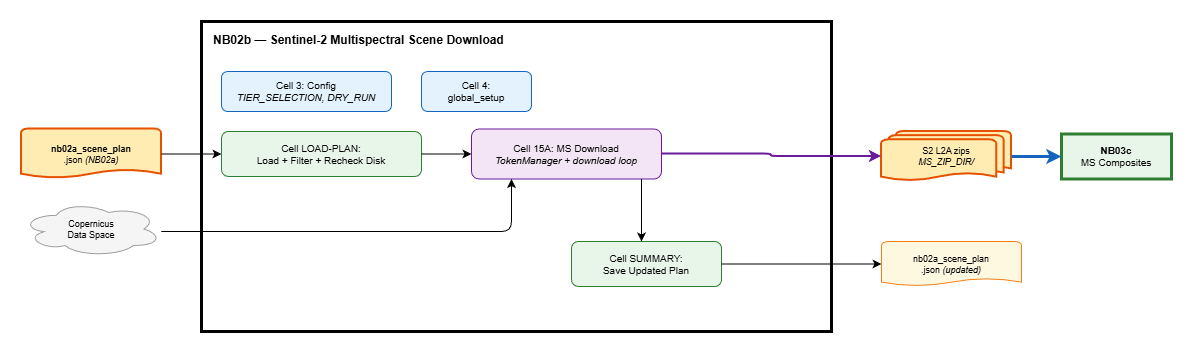

In [1]:
# @title CELL 3: NB02b CONFIG
TIER_SELECTION = [0, 1, 2,3,4,5]
CITY_SELECTION = None
FORCE_RERUN = False
DRY_RUN = False
MAX_DOWNLOADS = None
MAX_RETRIES = 3

In [2]:
# @title CELL 4: LOAD GLOBAL SETUP
import platform, os
if platform.system() == 'Windows':
    _setup = r'F:\PROJECTS\masterthesis\gdrive\masterthesis\notebooks\global_setup.py'
elif os.path.exists('/content/drive_f'):
    _setup = '/content/drive_f/masterthesis/notebooks/global_setup.py'
else:
    _setup = '/mnt/f/PROJECTS/masterthesis/gdrive/masterthesis/notebooks/global_setup.py'
with open(_setup) as f:
    exec(f.read())

/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


BDA GLOBAL SETUP
Started: 2026-04-09 21:22:36
Python: 3.12.12

[1/7] Directory Structure
----------------------------------------------------------------------
  GDrive (G:):       /content/drive_f/masterthesis OK
  GDrive (F:):       /content/drive_f/masterthesis OK
  Local data (G:):   /content/masterthesis_local/data OK
  Data stack (F:):   /mnt/f/PROJECTS/masterthesis/data_stack OK

  TIER_SELECTION: [0, 1, 2, 3, 4, 5]
  CITY_SELECTION: None (tier filter)
  REQUIRE_UNOSAT: False
  CITIES_TO_PROCESS: 50 cities

[2/7] Credentials
----------------------------------------------------------------------
  Copernicus: inf***
  OpenTopography: OK
  Earthdata: marcoheinzen

[3/7] Python Packages
----------------------------------------------------------------------


<string>:532: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.



  Already installed: 23
  Newly installed:   0
  Failed:            0

[4/7] Global Imports & Configuration
----------------------------------------------------------------------
  All imports loaded

[5/7] Processing Config & SNAP
----------------------------------------------------------------------
  GPT: Usage:
  Temporal baseline: 10-24 days
  Wavelength: 0.0555

[6/7] GPU Status
----------------------------------------------------------------------
  CUDA available: NVIDIA GeForce RTX 2070 SUPER
    CUDA version: 12.8

[7/7] Disk Space
----------------------------------------------------------------------
  GDrive (G:)     912.4/7452.0 GB (6539.7 GB free)
  GDrive (F:)     967.1/3726.0 GB (2758.9 GB free)
  Local data      12018.4/14901.9 GB (2883.5 GB free)
  Data stack      967.1/3726.0 GB (2758.9 GB free)
  WSL ext4        130.5/1006.9 GB (825.2 GB free)

GLOBAL SETUP COMPLETE
  Torch device: cuda
  Cities: 50, CITY=Avdiivka
  Functions: load_aoi(), load_aoi_gdf(), load_aoi_b

# LOAD PLAN + RECHECK DISK

In [3]:
# @title CELL LOAD-PLAN: LOAD PLAN + FILTER + RECHECK DISK
import json
from pathlib import Path
from datetime import datetime

PLAN_FILE = OUTPUTS_DIR / 'nb02a_scene_plan.json'
if not PLAN_FILE.exists():
    raise FileNotFoundError(f"Plan not found: {PLAN_FILE}\nRun NB02a first.")

with open(PLAN_FILE) as f:
    PLAN = json.load(f)

print("=" * 80)
print("NB02b: LOADING PLAN + RECHECKING MS ZIPS")
print("=" * 80)

ms_plan = {}
for city, plan in PLAN.items():
    tier = plan.get('tier', 99)
    if TIER_SELECTION and tier not in TIER_SELECTION:
        continue
    if CITY_SELECTION and city not in CITY_SELECTION:
        continue
    ms_plan[city] = plan

print(f"  Cities after filter: {len(ms_plan)}")

# Recheck zips on disk
import zipfile, re
MS_ZIP_DIR.mkdir(parents=True, exist_ok=True)

zip_stems = set()
for f in MS_ZIP_DIR.iterdir():
    if f.suffix == '.zip' and f.stat().st_size > 1024 * 1024:
        zip_stems.add(f.stem)

download_queue = []
on_disk_count = 0

for city, plan in sorted(ms_plan.items(), key=lambda x: (x[1]['tier'], x[0])):
    for entry in plan.get('ms', []):
        scene_name = entry.get('scene_name', '').replace('.SAFE', '')
        if scene_name and scene_name in zip_stems:
            entry['status'] = 'on_disk'
            on_disk_count += 1
        elif entry['status'] == 'on_disk':
            entry['status'] = 'to_download'
        if entry['status'] == 'to_download' and entry.get('scene_id'):
            download_queue.append({
                'city': city, 'tier': plan['tier'],
                'period': entry.get('period', ''), 'date': entry.get('date', ''),
                'scene_name': scene_name, 'scene_id': entry['scene_id'],
                'cloud_cover': entry.get('cloud_cover', -1),
            })

print(f"  On disk: {on_disk_count}")
print(f"  To download: {len(download_queue)}")
download_queue.sort(key=lambda x: (x['tier'], x['city'], x['date']))
print("=" * 80)

NB02b: LOADING PLAN + RECHECKING MS ZIPS
  Cities after filter: 50
  On disk: 1630
  To download: 0


# DOWNLOAD

In [4]:
# @title CELL 15A: MULTISPECTRAL SCENE DOWNLOAD (METADATA-BASED)
# =============================================================================
# Downloads Sentinel-2 L2A scenes listed in ms_scene_metadata.json (from Cell 14A1).
# Persistent zip storage in MS_ZIP_DIR for reuse across cities.
#
# Uses scene names + product IDs from metadata directly - no re-search.
# This ensures the correct tile (coverage-checked by scene discovery) is downloaded.
#
# Output: MS_ZIP_DIR/{scene_name}.zip (persistent cache, no extraction)
# Extraction handled by NB03c clip cell.
# Requires: Cell 4 (paths), Cell 14A1 (ms_scene_metadata.json)
# =============================================================================

import json
import os
import requests
from pathlib import Path
from datetime import datetime, timedelta
import zipfile
import time
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# CONFIGURATION
# =============================================================================

FORCE_RERUN = False
DRY_RUN = False
MAX_DOWNLOADS = None              # None = no limit
MAX_RETRIES = 3

COP_USER = os.environ.get('COP_U', '')
COP_PASS = os.environ.get('COP_PW', '')

MS_DOWNLOAD_TRACKING_FILE = OUTPUTS_DIR / 'ms_download_tracking_v2.json'

print("=" * 80)
print("CELL 15A: MULTISPECTRAL SCENE DOWNLOAD (METADATA-BASED)")
print("=" * 80)
print(f"  Timestamp:    {datetime.now().isoformat()}")
print(f"  Copernicus:   {COP_USER}")
print(f"  Tier filter:  {TIER_SELECTION}")
print(f"  City filter:  {CITY_SELECTION or 'ALL'}")
print(f"  DRY_RUN:      {DRY_RUN}")
print(f"  MS_ZIP_DIR:   {MS_ZIP_DIR}")
print(f"  MS_METADATA:  {MS_METADATA_DIR}")

# =============================================================================
# TOKEN MANAGER
# =============================================================================

class TokenManager:
    def __init__(self):
        self.token = None
        self.token_expiry = None

    def get_token(self):
        now = datetime.now()
        if self.token is None or self.token_expiry is None or now >= self.token_expiry - timedelta(minutes=2):
            self._renew_token()
        return self.token

    def _renew_token(self):
        token_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
        data = {
            "grant_type": "password",
            "username": COP_USER,
            "password": COP_PASS,
            "client_id": "cdse-public"
        }
        for attempt in range(3):
            try:
                response = requests.post(token_url, data=data, timeout=30)
                response.raise_for_status()
                token_data = response.json()
                self.token = token_data['access_token']
                expires_in = token_data.get('expires_in', 600)
                self.token_expiry = datetime.now() + timedelta(seconds=expires_in)
                return
            except Exception as e:
                if attempt < 2:
                    time.sleep(5 * (attempt + 1))
                else:
                    raise

token_manager = TokenManager()

# =============================================================================
# DOWNLOAD FUNCTION
# =============================================================================

def download_scene_zip(scene_id, scene_name, max_retries=MAX_RETRIES):
    """Download S2 scene zip to MS_ZIP_DIR by Copernicus product ID."""
    zip_path = MS_ZIP_DIR / f"{scene_name}.zip"

    # already cached?
    if zip_path.exists() and zip_path.stat().st_size > 1024*1024:
        if zipfile.is_zipfile(zip_path):
            return zip_path, 'cached'

    download_url = f"https://zipper.dataspace.copernicus.eu/odata/v1/Products({scene_id})/$value"
    tmp_path = MS_ZIP_DIR / f"{scene_name}.zip.tmp"

    for attempt in range(max_retries):
        try:
            token = token_manager.get_token()
            headers = {"Authorization": f"Bearer {token}"}

            with requests.get(download_url, headers=headers, stream=True, timeout=600) as resp:
                resp.raise_for_status()
                total = int(resp.headers.get('content-length', 0))

                with open(tmp_path, 'wb') as f:
                    downloaded = 0
                    for chunk in resp.iter_content(chunk_size=8192*16):
                        f.write(chunk)
                        downloaded += len(chunk)
                        if total > 0 and downloaded % (50*1024*1024) < 8192*16:
                            pct = downloaded / total * 100
                            print(f"      Progress: {pct:.0f}% ({downloaded/1e9:.2f}/{total/1e9:.2f} GB)", end='\r')

                if total > 0:
                    print(f"      Downloaded: {scene_name[:60]} ({total/1e6:.0f} MB)")

            # verify and rename
            if tmp_path.exists() and tmp_path.stat().st_size > 1024*1024:
                tmp_path.rename(zip_path)
                if zipfile.is_zipfile(zip_path):
                    return zip_path, 'downloaded'
                else:
                    print(f"      BAD ZIP after download, deleting")
                    zip_path.unlink()
            else:
                if tmp_path.exists():
                    tmp_path.unlink()

        except Exception as e:
            print(f"      Attempt {attempt+1} failed: {e}")
            if tmp_path.exists():
                tmp_path.unlink()
            if attempt < max_retries - 1:
                wait = 15 * (attempt + 1)
                print(f"      Retrying in {wait}s...")
                time.sleep(wait)
            else:
                raise

    return None, 'failed'

# =============================================================================
# LOAD/INIT TRACKING
# =============================================================================

def load_ms_tracking():
    if MS_DOWNLOAD_TRACKING_FILE.exists():
        with open(MS_DOWNLOAD_TRACKING_FILE, 'r') as f:
            return json.load(f)
    return {'targets': {}, 'timestamp': None}

def save_ms_tracking(tracking):
    tracking['timestamp'] = datetime.now().isoformat()
    with open(MS_DOWNLOAD_TRACKING_FILE, 'w') as f:
        json.dump(tracking, f, indent=2)

ms_tracking = load_ms_tracking()
print(f"  Tracking:     {len(ms_tracking['targets'])} targets tracked")

# =============================================================================
# COLLECT SCENES FROM PLAN (ms_plan from Cell LOAD-PLAN)
# =============================================================================

print(f"\n--- Loading scenes from plan (ms_plan, {len(ms_plan)} cities) ---\n")

download_tasks = []
seen_scene_names = set()

for city in sorted(ms_plan.keys(), key=lambda c: (ms_plan[c].get('tier', 99), c)):
    plan = ms_plan[city]
    tier = plan.get('tier', 99)
    city_scene_count = 0

    for entry in plan.get('ms', []):
        scene_name = entry.get('scene_name', '').replace('.SAFE', '')
        scene_id = entry.get('scene_id', '')
        if not scene_name or not scene_id:
            continue

        # deduplicate across cities (shared tiles)
        if scene_name in seen_scene_names:
            continue
        seen_scene_names.add(scene_name)

        download_tasks.append({
            'city': city,
            'period': entry.get('period', ''),
            'scene_name': scene_name,
            'scene_id': scene_id,
            'scene_date': entry.get('date', '')[:10],
            'cloud_cover': entry.get('cloud_cover', -1),
            'tier': tier,
        })
        city_scene_count += 1

    print(f"  {city:25s} T{tier}: {city_scene_count} scenes")

print(f"\n  Cities loaded:   {len(ms_plan)}")
print(f"  Unique scenes:   {len(download_tasks)}")

# =============================================================================
# CHECK ZIP CACHE
# =============================================================================

print(f"\n--- Checking existing zips ---\n")

MS_ZIP_DIR.mkdir(parents=True, exist_ok=True)
zip_cache = set()
for f in MS_ZIP_DIR.iterdir():
    if f.suffix == '.zip' and f.stat().st_size > 1024*1024:
        zip_cache.add(f.stem)

print(f"  Valid zips in cache: {len(zip_cache)}")

to_download = []
already_cached = 0
for task in download_tasks:
    if task['scene_name'] in zip_cache:
        already_cached += 1
    else:
        to_download.append(task)

print(f"  Already cached:      {already_cached}")
print(f"  To download:         {len(to_download)}")

# =============================================================================
# DOWNLOAD
# =============================================================================

if DRY_RUN:
    print(f"\n  DRY RUN - would download {len(to_download)} scenes")
    for t in to_download[:20]:
        print(f"    {t['city']}/{t['period']}/{t['scene_date']} <- {t['scene_name'][:60]}")
    if len(to_download) > 20:
        print(f"    ... and {len(to_download)-20} more")

elif to_download:
    print(f"\n{'='*80}")
    print(f"DOWNLOADING {len(to_download)} SCENES")
    print(f"{'='*80}")

    total_start = time.time()
    success_count = 0
    fail_count = 0

    for idx, task in enumerate(to_download, 1):
        if MAX_DOWNLOADS is not None and success_count >= MAX_DOWNLOADS:
            print(f"\n  Reached MAX_DOWNLOADS={MAX_DOWNLOADS}, stopping.")
            break

        city = task['city']
        period = task['period']
        scene_name = task['scene_name']
        scene_id = task['scene_id']
        scene_date = task['scene_date']
        cloud = task['cloud_cover']

        tracker_key = f"{city}_{period}_{scene_date}"

        # skip if tracked as success AND zip actually exists on disk
        if not FORCE_RERUN and tracker_key in ms_tracking['targets']:
            if ms_tracking['targets'][tracker_key].get('status') == 'success':
                if scene_name in zip_cache:
                    continue
                # ghost: tracker says success but zip missing -> reset and re-download
                print(f"  [{idx}/{len(to_download)}] GHOST: {city}/{scene_date} tracker=success but zip missing, re-downloading")
                del ms_tracking['targets'][tracker_key]

        print(f"\n  [{idx}/{len(to_download)}] {city} / {period} / {scene_date}  cloud={cloud:.1f}%")
        print(f"    {scene_name[:70]}")

        try:
            zip_path, dl_status = download_scene_zip(scene_id, scene_name)

            if zip_path:
                print(f"    {dl_status.upper()}: {zip_path.name[:60]}")

                ms_tracking['targets'][tracker_key] = {
                    'status': 'success',
                    'city': city,
                    'period': period,
                    'scene_name': scene_name,
                    'scene_id': scene_id,
                    'scene_date': scene_date,
                    'cloud_cover': cloud,
                    'zip_path': str(zip_path),
                    'source': dl_status,
                    'timestamp': datetime.now().isoformat(),
                }
                save_ms_tracking(ms_tracking)

                # write success back to plan
                PLAN_FILE = OUTPUTS_DIR / 'nb02a_scene_plan.json'
                for e in ms_plan.get(city, {}).get('ms', []):
                    if e.get('scene_name', '').replace('.SAFE', '') == scene_name:
                        e['status'] = 'on_disk'
                        break
                with open(PLAN_FILE) as rf:
                    full_plan = json.load(rf)
                full_plan.update(ms_plan)
                with open(PLAN_FILE, 'w') as pf:
                    json.dump(full_plan, pf, indent=2, default=str)

                success_count += 1
            else:
                print(f"    FAILED: no valid zip")
                ms_tracking['targets'][tracker_key] = {
                    'status': 'failed',
                    'city': city,
                    'period': period,
                    'scene_name': scene_name,
                    'scene_id': scene_id,
                    'timestamp': datetime.now().isoformat(),
                }
                save_ms_tracking(ms_tracking)
                fail_count += 1

        except Exception as e:
            print(f"    FAILED: {e}")
            fail_count += 1

    elapsed = time.time() - total_start

    print(f"\n{'='*80}")
    print(f"MS DOWNLOAD COMPLETE ({elapsed/60:.1f}min)")
    print(f"{'='*80}")
    print(f"  Downloaded:  {success_count}")
    print(f"  Failed:      {fail_count}")
    print(f"  Zip cache:   {len(zip_cache) + success_count} total")

else:
    print(f"\n  All {already_cached} scenes already in zip cache. Nothing to download.")

# =============================================================================
# SUMMARY: per-city zip status
# =============================================================================

print(f"\n  Per-city zip status:")
city_stats = {}
for task in download_tasks:
    c = task['city']
    if c not in city_stats:
        city_stats[c] = {'total': 0, 'cached': 0}
    city_stats[c]['total'] += 1
    if task['scene_name'] in zip_cache:
        city_stats[c]['cached'] += 1

for city in sorted(city_stats.keys()):
    s = city_stats[city]
    status = "COMPLETE" if s['cached'] == s['total'] else f"{s['total'] - s['cached']} to download"
    print(f"    {city:25s}: {s['cached']:3d}/{s['total']:3d} zips -> {status}")

print(f"\n{'='*80}")
print("CELL 15A COMPLETE")
print(f"{'='*80}")


CELL 15A: MULTISPECTRAL SCENE DOWNLOAD (METADATA-BASED)
  Timestamp:    2026-04-09T21:23:26.153578
  Copernicus:   info@marconicolasheinzen.com
  Tier filter:  [0, 1, 2, 3, 4, 5]
  City filter:  ALL
  DRY_RUN:      False
  MS_ZIP_DIR:   /content/masterthesis_local/data/ms_zip
  MS_METADATA:  /content/drive_f/masterthesis/data/satellite/MS/metadata
  Tracking:     3018 targets tracked

--- Loading scenes from plan (ms_plan, 50 cities) ---

  Avdiivka                  T0: 28 scenes
  Bakhmut                   T0: 3 scenes
  Mariupol                  T0: 12 scenes
  Sievierodonetsk           T0: 15 scenes
  Chasiv Yar                T1: 23 scenes
  Hirske                    T1: 0 scenes
  Krasnohorivka             T1: 35 scenes
  Kurakhove                 T1: 39 scenes
  Lysychansk                T1: 1 scenes
  Maryinka                  T1: 5 scenes
  New York                  T1: 1 scenes
  Pisky                     T1: 1 scenes
  Popasna                   T1: 0 scenes
  Rubizhne        

In [5]:
# @title CELL SUMMARY: NB02b COMPLETE
# Save updated plan
with open(PLAN_FILE, 'w') as f:
    json.dump(PLAN, f, indent=2, default=str)
print("=" * 80)
print("NB02b MS DOWNLOAD - COMPLETE")
print(f"  Plan updated: {PLAN_FILE}")
print("=" * 80)

NB02b MS DOWNLOAD - COMPLETE
  Plan updated: /content/drive_f/masterthesis/data/outputs/nb02a_scene_plan.json
